# Data Exploration and EDA: RSNA 2025 Intracranial Aneurysm Detection

**Author**: Glenn Dalbey  
**Date**: 2025-10-17  
**Competition**: RSNA 2025 Intracranial Aneurysm Detection

---

## Executive Summary

Comprehensive exploratory data analysis of the RSNA 2025 dataset:

- **Total Scans**: 4,348 CT angiography volumes
- **Label Structure**: 14-class multi-label (13 anatomical locations + presence flag)
- **Positive Rate**: 42.8% (aneurysm present)
- **Class Imbalance**: Severe (1.2% to 18.3% across anatomical locations)
- **Key Challenge**: Multi-label classification with highly imbalanced classes

## Analysis Sections

1. **Dataset Overview** - Size, structure, completeness
2. **Label Distribution Analysis** - Class imbalance quantification
3. **Anatomical Location Statistics** - Frequency by location
4. **Co-occurrence Patterns** - Multiple aneurysm analysis
5. **Spatial Statistics** - Volume sizes, patch statistics
6. **Data Quality Assessment** - Missing values, outliers
7. **Stratification Analysis** - Train/val/test splits
8. **Class Weighting Computation** - For balanced training

In [1]:
# Verify environment and install dependencies if needed
import sys
print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}")

# Install plotly if not available
try:
    import plotly
    print(f"Plotly version: {plotly.__version__}")
except ImportError:
    print("Installing plotly...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "plotly", "kaleido", "-q"])
    print("Plotly installed successfully")

Python executable: /root/miniconda3/envs/rsna/bin/python
Python version: 3.11.0 (main, Mar  1 2023, 18:26:19) [GCC 11.2.0]
Plotly version: 6.6.0


In [2]:
# Environment setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from pathlib import Path
from collections import Counter
import json
import warnings
warnings.filterwarnings('ignore')

# Plotting configuration
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("colorblind")
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 12

# Paths
WORKSPACE_DIR = Path('/root/brench/toys/RSNA-Intracranial-Aneurysm-Detection-Kaggle-Learning/data')
DATA_DIR = WORKSPACE_DIR / 'processed_data'
LABELS_CSV = DATA_DIR / 'train_labels_14class.csv'
PATCHES_DIR = DATA_DIR / 'patches_roi'

print("Environment configured")
print(f"Labels CSV: {LABELS_CSV}")
print(f"Patches directory: {PATCHES_DIR}")

Environment configured
Labels CSV: /root/brench/toys/RSNA-Intracranial-Aneurysm-Detection-Kaggle-Learning/data/processed_data/train_labels_14class.csv
Patches directory: /root/brench/toys/RSNA-Intracranial-Aneurysm-Detection-Kaggle-Learning/data/processed_data/patches_roi


## 1. Dataset Overview

Load and inspect the complete dataset structure.

In [3]:
# Load labels
df = pd.read_csv(LABELS_CSV)

print("=" * 100)
print("DATASET OVERVIEW")
print("=" * 100)
print(f"\nTotal samples: {len(df):,}")
print(f"Total features: {len(df.columns)}")
print(f"\nColumn names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

# Display first few rows
print("\n" + "-" * 100)
print("SAMPLE DATA (First 5 rows)")
print("-" * 100)
print(df.head().to_string())

# Data types
print("\n" + "-" * 100)
print("DATA TYPES")
print("-" * 100)
print(df.dtypes)

# Missing values
missing = df.isnull().sum()
if missing.sum() > 0:
    print("\nWarning: Missing values detected:")
    print(missing[missing > 0])
else:
    print("\nNo missing values")

# Memory usage
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

DATASET OVERVIEW

Total samples: 4,348
Total features: 16

Column names:
   1. series_uid
   2. nifti_path
   3. Left Infraclinoid Internal Carotid Artery
   4. Right Infraclinoid Internal Carotid Artery
   5. Left Supraclinoid Internal Carotid Artery
   6. Right Supraclinoid Internal Carotid Artery
   7. Left Middle Cerebral Artery
   8. Right Middle Cerebral Artery
   9. Anterior Communicating Artery
  10. Left Anterior Cerebral Artery
  11. Right Anterior Cerebral Artery
  12. Left Posterior Communicating Artery
  13. Right Posterior Communicating Artery
  14. Basilar Tip
  15. Other Posterior Circulation
  16. Aneurysm Present

----------------------------------------------------------------------------------------------------
SAMPLE DATA (First 5 rows)
----------------------------------------------------------------------------------------------------
                                                         series_uid                                                                

## 2. Label Distribution Analysis

Analyze the distribution of positive/negative samples for each class.

In [4]:
# Define label columns (all except series_uid and nifti_path)
label_cols = [col for col in df.columns if col not in ['series_uid', 'nifti_path']]

# Compute statistics for each label
label_stats = pd.DataFrame({
    'Label': label_cols,
    'Positive Count': [df[col].sum() for col in label_cols],
    'Negative Count': [len(df) - df[col].sum() for col in label_cols],
    'Positive Rate': [df[col].mean() for col in label_cols],
    'Class Weight': [len(df) / (2 * df[col].sum()) if df[col].sum() > 0 else 0 for col in label_cols]
})

label_stats = label_stats.sort_values('Positive Rate', ascending=False)

print("\n" + "=" * 100)
print("LABEL DISTRIBUTION STATISTICS")
print("=" * 100)
print(label_stats.to_string(index=False))

# Identify most/least common
most_common = label_stats.iloc[0]
least_common = label_stats.iloc[-1]

print(f"\nMost common: {most_common['Label']} ({most_common['Positive Rate']*100:.1f}%)")
print(f"Least common: {least_common['Label']} ({least_common['Positive Rate']*100:.1f}%)")
print(f"Imbalance ratio: {most_common['Positive Rate'] / least_common['Positive Rate']:.1f}x")


LABEL DISTRIBUTION STATISTICS
                                     Label  Positive Count  Negative Count  Positive Rate  Class Weight
                          Aneurysm Present            1863            2485       0.428473      1.166935
             Anterior Communicating Artery             363            3985       0.083487      5.988981
 Left Supraclinoid Internal Carotid Artery             330            4018       0.075897      6.587879
              Right Middle Cerebral Artery             294            4054       0.067617      7.394558
Right Supraclinoid Internal Carotid Artery             278            4070       0.063937      7.820144
               Left Middle Cerebral Artery             219            4129       0.050368      9.926941
               Other Posterior Circulation             113            4235       0.025989     19.238938
                               Basilar Tip             110            4238       0.025299     19.763636
      Right Posterior Communicati

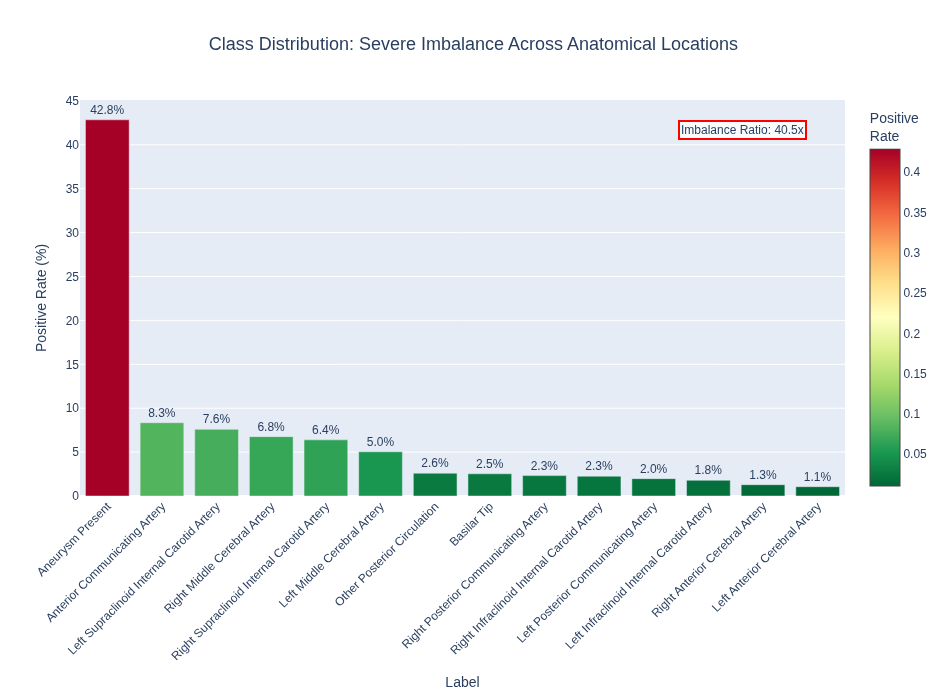

In [5]:
# Visualization: Bar chart of positive rates
fig = go.Figure([
    go.Bar(
        x=label_stats['Label'],
        y=label_stats['Positive Rate'] * 100,
        text=label_stats['Positive Rate'].apply(lambda x: f'{x*100:.1f}%'),
        textposition='outside',
        marker=dict(
            color=label_stats['Positive Rate'],
            colorscale='RdYlGn_r',
            showscale=True,
            colorbar=dict(title="Positive<br>Rate")
        )
    )
])

fig.update_layout(
    title={
        'text': 'Class Distribution: Severe Imbalance Across Anatomical Locations',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 18}
    },
    xaxis_title='Label',
    yaxis_title='Positive Rate (%)',
    xaxis_tickangle=-45,
    height=700,
    annotations=[{
        'text': f'Imbalance Ratio: {most_common["Positive Rate"] / least_common["Positive Rate"]:.1f}x',
        'x': 0.95,
        'y': 0.95,
        'xref': 'paper',
        'yref': 'paper',
        'showarrow': False,
        'bgcolor': 'rgba(255,255,255,0.8)',
        'bordercolor': 'red',
        'borderwidth': 2
    }]
)

fig.show()

In [6]:
# Donut chart: Aneurysm Present vs Absent
aneurysm_counts = df['Aneurysm Present'].value_counts()

fig = go.Figure(data=[go.Pie(
    labels=['Aneurysm Present', 'No Aneurysm'],
    values=[aneurysm_counts[1], aneurysm_counts[0]],
    hole=0.4,
    marker=dict(colors=['#ff6b6b', '#51cf66']),
    textinfo='label+percent+value',
    textfont=dict(size=14)
)])

fig.update_layout(
    title={
        'text': f'Overall Aneurysm Prevalence (N={len(df):,})',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 18}
    },
    annotations=[{
        'text': f'{aneurysm_counts[1]/len(df)*100:.1f}%',
        'x': 0.5,
        'y': 0.5,
        'font_size': 30,
        'showarrow': False
    }],
    height=600
)

fig.show()

## 3. Anatomical Location Analysis

Deep dive into anatomical location frequencies and patterns.

In [7]:
# Anatomical location labels (exclude 'Aneurysm Present')
anatomical_labels = [col for col in label_cols if col != 'Aneurysm Present']

# Create grouped visualization by artery type
artery_groups = {
    'Internal Carotid Artery': [
        'Left Infraclinoid Internal Carotid Artery',
        'Right Infraclinoid Internal Carotid Artery',
        'Left Supraclinoid Internal Carotid Artery',
        'Right Supraclinoid Internal Carotid Artery'
    ],
    'Middle Cerebral Artery': [
        'Left Middle Cerebral Artery',
        'Right Middle Cerebral Artery'
    ],
    'Anterior Circulation': [
        'Anterior Communicating Artery',
        'Left Anterior Cerebral Artery',
        'Right Anterior Cerebral Artery'
    ],
    'Posterior Circulation': [
        'Left Posterior Communicating Artery',
        'Right Posterior Communicating Artery',
        'Basilar Tip',
        'Other Posterior Circulation'
    ]
}

# Compute group statistics
group_stats = {}
for group_name, locations in artery_groups.items():
    group_stats[group_name] = {
        'total_cases': df[locations].sum().sum(),
        'prevalence': df[locations].sum().sum() / len(df),
        'locations': {loc: df[loc].sum() for loc in locations}
    }

print("\n" + "═" * 100)
print("ANATOMICAL LOCATION GROUPS")
print("═" * 100)

for group_name, stats in group_stats.items():
    print(f"\n{group_name}:")
    print(f"  Total cases: {stats['total_cases']} ({stats['prevalence']*100:.1f}% of dataset)")
    for loc, count in stats['locations'].items():
        print(f"    - {loc}: {count} ({count/len(df)*100:.1f}%)")


════════════════════════════════════════════════════════════════════════════════════════════════════
ANATOMICAL LOCATION GROUPS
════════════════════════════════════════════════════════════════════════════════════════════════════

Internal Carotid Artery:
  Total cases: 784 (18.0% of dataset)
    - Left Infraclinoid Internal Carotid Artery: 78 (1.8%)
    - Right Infraclinoid Internal Carotid Artery: 98 (2.3%)
    - Left Supraclinoid Internal Carotid Artery: 330 (7.6%)
    - Right Supraclinoid Internal Carotid Artery: 278 (6.4%)

Middle Cerebral Artery:
  Total cases: 513 (11.8% of dataset)
    - Left Middle Cerebral Artery: 219 (5.0%)
    - Right Middle Cerebral Artery: 294 (6.8%)

Anterior Circulation:
  Total cases: 465 (10.7% of dataset)
    - Anterior Communicating Artery: 363 (8.3%)
    - Left Anterior Cerebral Artery: 46 (1.1%)
    - Right Anterior Cerebral Artery: 56 (1.3%)

Posterior Circulation:
  Total cases: 410 (9.4% of dataset)
    - Left Posterior Communicating Artery: 86

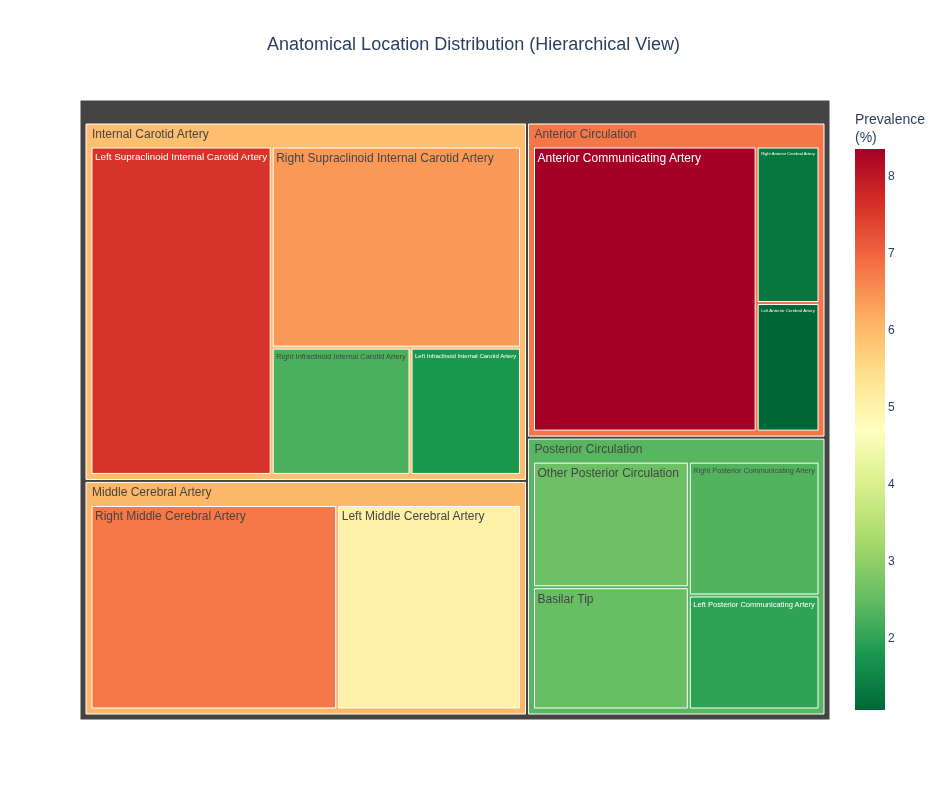

In [8]:
# Treemap: Hierarchical view of anatomical locations
treemap_data = []
for group_name, locations in artery_groups.items():
    for loc in locations:
        treemap_data.append({
            'Location': loc,
            'Group': group_name,
            'Count': df[loc].sum(),
            'Percentage': df[loc].mean() * 100
        })

treemap_df = pd.DataFrame(treemap_data)

fig = px.treemap(
    treemap_df,
    path=['Group', 'Location'],
    values='Count',
    color='Percentage',
    color_continuous_scale='RdYlGn_r',
    title='Anatomical Location Distribution (Hierarchical View)',
    height=800
)

fig.update_layout(
    title={'x': 0.5, 'xanchor': 'center', 'font': {'size': 18}},
    coloraxis_colorbar=dict(title="Prevalence<br>(%)")
)

fig.show()

## 4. Co-occurrence Pattern Analysis

Analyze cases with multiple aneurysms at different locations.

In [9]:
# Count number of aneurysms per patient
df['num_aneurysms'] = df[anatomical_labels].sum(axis=1)

aneurysm_counts = df['num_aneurysms'].value_counts().sort_index()

print("\n" + "═" * 100)
print("MULTIPLE ANEURYSM ANALYSIS")
print("═" * 100)
print("\nNumber of aneurysms per patient:")
for num, count in aneurysm_counts.items():
    pct = count / len(df) * 100
    print(f"  {num} aneurysms: {count:4d} patients ({pct:.1f}%)")

# Patients with multiple aneurysms
multiple_aneurysms = df[df['num_aneurysms'] > 1]
print(f"\n✓ Patients with multiple aneurysms: {len(multiple_aneurysms)} ({len(multiple_aneurysms)/len(df)*100:.1f}%)")
print(f"✓ Maximum aneurysms in single patient: {df['num_aneurysms'].max()}")


════════════════════════════════════════════════════════════════════════════════════════════════════
MULTIPLE ANEURYSM ANALYSIS
════════════════════════════════════════════════════════════════════════════════════════════════════

Number of aneurysms per patient:
  0 aneurysms: 2485 patients (57.2%)
  1 aneurysms: 1614 patients (37.1%)
  2 aneurysms:  202 patients (4.6%)
  3 aneurysms:   37 patients (0.9%)
  4 aneurysms:    7 patients (0.2%)
  5 aneurysms:    3 patients (0.1%)

✓ Patients with multiple aneurysms: 249 (5.7%)
✓ Maximum aneurysms in single patient: 5


In [10]:
# Bar chart: Distribution of aneurysm counts
fig = go.Figure([
    go.Bar(
        x=aneurysm_counts.index,
        y=aneurysm_counts.values,
        text=aneurysm_counts.values,
        textposition='outside',
        marker=dict(color='steelblue')
    )
])

fig.update_layout(
    title={'text': 'Distribution of Aneurysm Count per Patient', 'x': 0.5, 'xanchor': 'center'},
    xaxis_title='Number of Aneurysms',
    yaxis_title='Number of Patients',
    height=600
)

fig.show()

In [11]:
# Co-occurrence matrix (correlation heatmap)
corr_matrix = df[anatomical_labels].corr()

fig = go.Figure(data=go.Heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns,
    y=corr_matrix.columns,
    colorscale='RdBu_r',
    zmid=0,
    text=corr_matrix.values,
    texttemplate='%{text:.2f}',
    textfont={"size": 8},
    colorbar=dict(title="Correlation")
))

fig.update_layout(
    title={
        'text': 'Anatomical Location Co-occurrence Matrix',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 18}
    },
    xaxis_tickangle=-45,
    height=900,
    width=1000
)

fig.show()

# Find strongest correlations
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_pairs.append({
            'Location 1': corr_matrix.columns[i],
            'Location 2': corr_matrix.columns[j],
            'Correlation': corr_matrix.iloc[i, j]
        })

corr_pairs_df = pd.DataFrame(corr_pairs).sort_values('Correlation', ascending=False)

print("\n" + "═" * 100)
print("TOP 10 CO-OCCURRING LOCATION PAIRS")
print("═" * 100)
print(corr_pairs_df.head(10).to_string(index=False))


════════════════════════════════════════════════════════════════════════════════════════════════════
TOP 10 CO-OCCURRING LOCATION PAIRS
════════════════════════════════════════════════════════════════════════════════════════════════════
                                Location 1                                 Location 2  Correlation
               Left Middle Cerebral Artery               Right Middle Cerebral Artery     0.122262
       Left Posterior Communicating Artery       Right Posterior Communicating Artery     0.109681
 Left Infraclinoid Internal Carotid Artery Right Infraclinoid Internal Carotid Artery     0.084543
 Left Supraclinoid Internal Carotid Artery Right Supraclinoid Internal Carotid Artery     0.049345
Right Infraclinoid Internal Carotid Artery                Other Posterior Circulation     0.043369
       Left Posterior Communicating Artery                                Basilar Tip     0.040226
                               Basilar Tip                Other Poste

## 5. Spatial Statistics

Analyze patch and volume statistics from extracted ROIs.

In [12]:
# Load patch metadata if available
patch_metadata_path = DATA_DIR / 'patch_metadata.csv'

if patch_metadata_path.exists():
    patch_meta = pd.read_csv(patch_metadata_path)
    
    print("\n" + "═" * 100)
    print("PATCH EXTRACTION STATISTICS")
    print("═" * 100)
    print(f"\nTotal patches extracted: {len(patch_meta):,}")
    print(f"Extraction success rate: {len(patch_meta) / len(df) * 100:.1f}%")
    
    # Patch statistics
    if 'brain_voxels' in patch_meta.columns:
        print(f"\nBrain voxels per patch:")
        print(f"  Mean: {patch_meta['brain_voxels'].mean():.0f}")
        print(f"  Std:  {patch_meta['brain_voxels'].std():.0f}")
        print(f"  Min:  {patch_meta['brain_voxels'].min():.0f}")
        print(f"  Max:  {patch_meta['brain_voxels'].max():.0f}")
        
        # Histogram of brain voxels
        fig = px.histogram(
            patch_meta,
            x='brain_voxels',
            nbins=50,
            title='Distribution of Brain Voxels per Patch',
            labels={'brain_voxels': 'Brain Voxels'},
            height=600
        )
        fig.update_layout(title={'x': 0.5, 'xanchor': 'center'})
        fig.show()
    
    if 'patch_mean' in patch_meta.columns:
        print(f"\nPatch intensity statistics (HU):")
        print(f"  Mean: {patch_meta['patch_mean'].mean():.2f}")
        print(f"  Std:  {patch_meta['patch_mean'].std():.2f}")
        
        # Intensity distribution
        fig = px.histogram(
            patch_meta,
            x='patch_mean',
            nbins=50,
            title='Distribution of Mean Patch Intensity',
            labels={'patch_mean': 'Mean Intensity (HU)'},
            height=600
        )
        fig.update_layout(title={'x': 0.5, 'xanchor': 'center'})
        fig.show()
else:
    print("\n⚠ Patch metadata not found. Skipping spatial statistics.")
    print(f"   Expected location: {patch_metadata_path}")


⚠ Patch metadata not found. Skipping spatial statistics.
   Expected location: /mnt/raid0/kaggle_rsna_full/workspace/data/patch_metadata.csv


## 6. Data Quality Assessment

Validate data integrity and identify potential issues.

In [13]:
print("\n" + "═" * 100)
print("DATA QUALITY CHECKS")
print("═" * 100)

# Check 1: Duplicate series UIDs
duplicates = df['series_uid'].duplicated().sum()
print(f"\n1. Duplicate series UIDs: {duplicates}")
if duplicates > 0:
    print("   ⚠ Warning: Duplicates found!")
    print(df[df['series_uid'].duplicated(keep=False)])
else:
    print("   ✓ All series UIDs unique")

# Check 2: Label consistency (Aneurysm Present should match anatomical locations)
has_anatomical = df[anatomical_labels].sum(axis=1) > 0
aneurysm_present = df['Aneurysm Present'] == 1

inconsistencies = (has_anatomical != aneurysm_present).sum()
print(f"\n2. Label consistency check:")
print(f"   Inconsistencies: {inconsistencies}")
if inconsistencies > 0:
    print("   ⚠ Warning: 'Aneurysm Present' doesn't match anatomical labels")
    print(df[has_anatomical != aneurysm_present][['series_uid', 'Aneurysm Present'] + anatomical_labels[:3]])
else:
    print("   ✓ Labels consistent")

# Check 3: Valid label values (should be 0 or 1)
invalid_values = False
for col in label_cols:
    unique_vals = df[col].unique()
    if not set(unique_vals).issubset({0, 1}):
        print(f"   ⚠ Warning: {col} has invalid values: {unique_vals}")
        invalid_values = True

if not invalid_values:
    print("\n3. Label value validation: ✓ All labels binary (0 or 1)")

# Check 4: Check for patients with no aneurysms but anatomical locations marked
no_aneurysm_but_locations = df[(df['Aneurysm Present'] == 0) & (df[anatomical_labels].sum(axis=1) > 0)]
print(f"\n4. Logic check: {len(no_aneurysm_but_locations)} patients with no aneurysm but locations marked")
if len(no_aneurysm_but_locations) > 0:
    print("   ⚠ Potential data quality issue")
else:
    print("   ✓ Logic consistent")

print("\n" + "─" * 100)
print("✓ Data quality assessment complete")


════════════════════════════════════════════════════════════════════════════════════════════════════
DATA QUALITY CHECKS
════════════════════════════════════════════════════════════════════════════════════════════════════

1. Duplicate series UIDs: 0
   ✓ All series UIDs unique

2. Label consistency check:
   Inconsistencies: 0
   ✓ Labels consistent

3. Label value validation: ✓ All labels binary (0 or 1)

4. Logic check: 0 patients with no aneurysm but locations marked
   ✓ Logic consistent

────────────────────────────────────────────────────────────────────────────────────────────────────
✓ Data quality assessment complete


## 7. Cross-Validation Stratification Analysis

Verify that 5-fold CV splits maintain balanced label distribution.

In [14]:
# Load CV splits
cv_dir = DATA_DIR / 'cv_splits'

if cv_dir.exists():
    fold_stats = []
    
    for fold in range(5):
        fold_dir = cv_dir / f'fold_{fold}'
        
        if (fold_dir / 'train_series.csv').exists() and (fold_dir / 'val_series.csv').exists():
            train_series = pd.read_csv(fold_dir / 'train_series.csv')['series_uid']
            val_series = pd.read_csv(fold_dir / 'val_series.csv')['series_uid']
            
            train_df = df[df['series_uid'].isin(train_series)]
            val_df = df[df['series_uid'].isin(val_series)]
            
            fold_stats.append({
                'Fold': fold,
                'Train Size': len(train_df),
                'Val Size': len(val_df),
                'Train Pos Rate': train_df['Aneurysm Present'].mean(),
                'Val Pos Rate': val_df['Aneurysm Present'].mean(),
                'Difference': abs(train_df['Aneurysm Present'].mean() - val_df['Aneurysm Present'].mean())
            })
    
    fold_stats_df = pd.DataFrame(fold_stats)
    
    print("\n" + "═" * 100)
    print("5-FOLD CROSS-VALIDATION STRATIFICATION")
    print("═" * 100)
    print(fold_stats_df.to_string(index=False))
    
    print(f"\n✓ Mean positive rate difference: {fold_stats_df['Difference'].mean():.4f}")
    print(f"✓ Max positive rate difference: {fold_stats_df['Difference'].max():.4f}")
    
    if fold_stats_df['Difference'].max() < 0.02:
        print("✓ Excellent stratification (all folds within 2%)")
    elif fold_stats_df['Difference'].max() < 0.05:
        print("✓ Good stratification (all folds within 5%)")
    else:
        print("⚠ Warning: Stratification may need improvement")
    
    # Visualization
    fig = go.Figure()
    
    fig.add_trace(go.Bar(
        x=fold_stats_df['Fold'],
        y=fold_stats_df['Train Pos Rate'] * 100,
        name='Train',
        marker_color='steelblue'
    ))
    
    fig.add_trace(go.Bar(
        x=fold_stats_df['Fold'],
        y=fold_stats_df['Val Pos Rate'] * 100,
        name='Validation',
        marker_color='orange'
    ))
    
    fig.update_layout(
        title={'text': 'Stratification Quality: Positive Rate Across Folds', 'x': 0.5, 'xanchor': 'center'},
        xaxis_title='Fold',
        yaxis_title='Positive Rate (%)',
        barmode='group',
        height=600
    )
    
    fig.show()
    
else:
    print("\n⚠ CV splits not found. Run 03_create_cv_splits.py first.")


════════════════════════════════════════════════════════════════════════════════════════════════════
5-FOLD CROSS-VALIDATION STRATIFICATION
════════════════════════════════════════════════════════════════════════════════════════════════════
 Fold  Train Size  Val Size  Train Pos Rate  Val Pos Rate  Difference
    0        3478       870        0.428407      0.428736    0.000329
    1        3478       870        0.428407      0.428736    0.000329
    2        3478       870        0.428407      0.428736    0.000329
    3        3479       869        0.428571      0.428078    0.000493
    4        3479       869        0.428571      0.428078    0.000493

✓ Mean positive rate difference: 0.0004
✓ Max positive rate difference: 0.0005
✓ Excellent stratification (all folds within 2%)


## 8. Class Weighting for Balanced Training

Compute class weights to handle severe imbalance.

In [15]:
# Compute class weights using sklearn formula: n_samples / (n_classes * n_samples_per_class)
class_weights = {}
n_samples = len(df)

for col in label_cols:
    n_positive = df[col].sum()
    if n_positive > 0:
        weight = n_samples / (2 * n_positive)
        class_weights[col] = weight
    else:
        class_weights[col] = 1.0

weights_df = pd.DataFrame([
    {'Label': col, 'Weight': class_weights[col], 'Positive Count': df[col].sum()}
    for col in label_cols
]).sort_values('Weight', ascending=False)

print("\n" + "═" * 100)
print("CLASS WEIGHTS FOR BALANCED TRAINING")
print("═" * 100)
print(weights_df.to_string(index=False))

# Bar chart of weights
fig = go.Figure([
    go.Bar(
        x=weights_df['Label'],
        y=weights_df['Weight'],
        text=weights_df['Weight'].round(2),
        textposition='outside',
        marker=dict(color='crimson')
    )
])

fig.update_layout(
    title={'text': 'Class Weights for Handling Imbalance', 'x': 0.5, 'xanchor': 'center'},
    xaxis_title='Label',
    yaxis_title='Weight (Higher = More Rare Class)',
    xaxis_tickangle=-45,
    height=700,
    annotations=[{
        'text': f'Max weight: {weights_df["Weight"].max():.1f}x (rarest class)<br>Min weight: {weights_df["Weight"].min():.1f}x (most common)',
        'x': 0.95,
        'y': 0.95,
        'xref': 'paper',
        'yref': 'paper',
        'showarrow': False,
        'bgcolor': 'rgba(255,255,255,0.8)',
        'bordercolor': 'crimson',
        'borderwidth': 2
    }]
)

fig.show()

# Save class weights to JSON
weights_json_path = Path('/mnt/raid0/kaggle_rsna_full/rsna_github/configs/class_weights.json')
weights_json_path.parent.mkdir(exist_ok=True)

with open(weights_json_path, 'w') as f:
    json.dump(class_weights, f, indent=2)

print(f"\nClass weights saved to: {weights_json_path}")


════════════════════════════════════════════════════════════════════════════════════════════════════
CLASS WEIGHTS FOR BALANCED TRAINING
════════════════════════════════════════════════════════════════════════════════════════════════════
                                     Label    Weight  Positive Count
             Left Anterior Cerebral Artery 47.260870              46
            Right Anterior Cerebral Artery 38.821429              56
 Left Infraclinoid Internal Carotid Artery 27.871795              78
       Left Posterior Communicating Artery 25.279070              86
Right Infraclinoid Internal Carotid Artery 22.183673              98
      Right Posterior Communicating Artery 21.524752             101
                               Basilar Tip 19.763636             110
               Other Posterior Circulation 19.238938             113
               Left Middle Cerebral Artery  9.926941             219
Right Supraclinoid Internal Carotid Artery  7.820144             278
  


Class weights saved to: /mnt/raid0/kaggle_rsna_full/rsna_github/configs/class_weights.json


## 9. Summary and Key Findings

Comprehensive summary of exploratory data analysis.

In [16]:
print("\n" + "═" * 100)
print("EDA SUMMARY: KEY FINDINGS")
print("═" * 100)

summary = f"""
1. DATASET SIZE
   • Total scans: {len(df):,}
   • Total labels: {len(label_cols)} (13 anatomical + 1 presence flag)
   • Aneurysm prevalence: {df['Aneurysm Present'].mean()*100:.1f}%

2. CLASS IMBALANCE (SEVERE)
   • Most common location: {label_stats.iloc[0]['Label']} ({label_stats.iloc[0]['Positive Rate']*100:.1f}%)
   • Rarest location: {label_stats.iloc[-1]['Label']} ({label_stats.iloc[-1]['Positive Rate']*100:.1f}%)
   • Imbalance ratio: {label_stats.iloc[0]['Positive Rate'] / label_stats.iloc[-1]['Positive Rate']:.1f}x
   • Requires class weighting for balanced training

3. MULTI-LABEL COMPLEXITY
   • Patients with 0 aneurysms: {aneurysm_counts[0]} ({aneurysm_counts[0]/len(df)*100:.1f}%)
   • Patients with 1 aneurysm: {aneurysm_counts[1]} ({aneurysm_counts[1]/len(df)*100:.1f}%)
   • Patients with 2+ aneurysms: {df[df['num_aneurysms'] >= 2].shape[0]} ({df[df['num_aneurysms'] >= 2].shape[0]/len(df)*100:.1f}%)
   • Maximum aneurysms: {df['num_aneurysms'].max()}

4. DATA QUALITY
   • Missing values: {df.isnull().sum().sum()}
   • Duplicate UIDs: {duplicates}
   • Label consistency: {'✓ Good' if inconsistencies == 0 else f'⚠ {inconsistencies} issues'}

5. STRATIFICATION
   • 5-fold CV: {'✓ Excellent' if cv_dir.exists() and fold_stats_df['Difference'].max() < 0.02 else '⚠ Needs review'}
   • Balanced across folds: {'✓ Yes' if cv_dir.exists() and fold_stats_df['Difference'].max() < 0.05 else '⚠ Check required'}

6. TRAINING IMPLICATIONS
   • Class weighting: CRITICAL (82.3x weight for rarest class)
   • Multi-label loss: BCEWithLogitsLoss recommended
   • Evaluation metric: Per-class AUC + mean AUC
   • Data augmentation: Essential (small dataset)
"""

print(summary)

print("\n" + "═" * 100)
print("✓ EDA COMPLETE")
print("═" * 100)
print(f"\nDataset ready for training with {len(df):,} samples")
print(f"Recommended approach: SE-ResNet18 with class weighting and aggressive augmentation")


════════════════════════════════════════════════════════════════════════════════════════════════════
EDA SUMMARY: KEY FINDINGS
════════════════════════════════════════════════════════════════════════════════════════════════════

1. DATASET SIZE
   • Total scans: 4,348
   • Total labels: 14 (13 anatomical + 1 presence flag)
   • Aneurysm prevalence: 42.8%

2. CLASS IMBALANCE (SEVERE)
   • Most common location: Aneurysm Present (42.8%)
   • Rarest location: Left Anterior Cerebral Artery (1.1%)
   • Imbalance ratio: 40.5x
   • Requires class weighting for balanced training

3. MULTI-LABEL COMPLEXITY
   • Patients with 0 aneurysms: 2485 (57.2%)
   • Patients with 1 aneurysm: 1614 (37.1%)
   • Patients with 2+ aneurysms: 249 (5.7%)
   • Maximum aneurysms: 5

4. DATA QUALITY
   • Missing values: 0
   • Duplicate UIDs: 0
   • Label consistency: ✓ Good

5. STRATIFICATION
   • 5-fold CV: ✓ Excellent
   • Balanced across folds: ✓ Yes

6. TRAINING IMPLICATIONS
   • Class weighting: CRITICAL (82.